<a href="https://colab.research.google.com/github/hyunbin1024/GEOG761/blob/lab2/761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [1]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet
!pip install mss --quiet

In [2]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='basic-thinker-504003-q7')

In [3]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [4]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [5]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

s2_max = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .max() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

s2_min = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .min() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

s2_mosaic = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .mosaic() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

In [6]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(s2_max, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 Max')
Map.addLayer(s2_min, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 Min')
Map.addLayer(s2_mosaic, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 Mosaic')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [7]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thinking there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [8]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [9]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [10]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [11]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [12]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [13]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)

# Define a common visualization palette and labels for WorldCover classes
landcover_names = [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare / sparse vegetation",
    "Snow and ice",
    "Permanent water bodies",
    "Herbaceous wetland",
    "Moss and lichen"
]

# Colors in hexadecimal format for the legend and visualization.
landcover_colors = [
    "006400",
    "ffbb22",
    "ffff4c",
    "f096ff",
    "fa0000",
    "b4b4b4",
    "f0f0f0",
    "0064c8",
    "0096a0",
    "fae6a0"
]

# Create a dictionary for the legend, mapping labels to colors.
legend_dict = dict(zip(landcover_names, landcover_colors))

# Visualization parameters for classified and remapped landcover
# The min and max correspond to the remapped class values (1-10)
classified_viz = {
    'min': 1,
    'max': 10,
    'palette': landcover_colors
}

# Add the classified layer with the defined visualization
Map.addLayer(classified, classified_viz, 'Classified')
# Add the ESA Landcover layer with the same defined visualization for consistency
Map.addLayer(landcover_remapped, classified_viz ,'ESA Landcover')

# Add legends for each layer
# Using the same legend_dict as both layers represent the same classification scheme.
Map.add_legend(title="RF Classified Landcover", legend_dict=legend_dict, position='bottomleft')
Map.add_legend(title="ESA WorldCover Landcover", legend_dict=legend_dict, position='bottomright')

Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


### Test Set Accuracy for 2020 Data

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Classify the test set
tested = test.classify(classifier, 'predicted')

# Get predicted vs actual from test set
y_true_test, y_pred_test = fc_to_lists(tested, 'Map_remapped', 'predicted')

# Labels for original classes (reusing from Zsjs-kDeeRMz)
# label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
# label_names = [label_map[i + 1] for i in range(10)] # These are already defined after running Zsjs-kDeeRMz

# Confusion matrix for test set
cm_test = confusion_matrix(y_true_test, y_pred_test, labels=list(range(1, 11)))
report_test = classification_report(y_true_test, y_pred_test, labels=list(range(1, 11)), target_names=[str(l) for l in label_names], zero_division=0)

# Pretty-print test confusion matrix and classification report
print("Test Confusion Matrix:")
print(pd.DataFrame(cm_test, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nTest Classification Report:")
print(report_test)

Test Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10        94        0        9        0        3        0        0   
Actual 20         0        0        0        0        0        0        0   
Actual 30        21        0       64        0        0        0        0   
Actual 40         0        0        1        0        0        0        0   
Actual 50         3        0        1        0       15        1        0   
Actual 60         0        0        0        0        2        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        1        0        0   
Actual 90         1        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual

---

### Landcover Maps for 2018, 2022, and 2024

Next, I will generate the classified landcover maps for 2018, 2022, and 2024 using the same Random Forest classifier trained on 2020 data. Each map will be displayed with its respective legend.

In [16]:
import geemap
import geopandas as gpd
import pandas as pd
from IPython.display import Image # Import Image for displaying static files
import os # Import the os module for path operations
import numpy as np

# Function to generate and classify Sentinel-2 image for a given year
def get_classified_image_for_year(year, aoi, classifier, bands, mask_s2_clouds):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'

    s2_collection_year = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                          .filterBounds(aoi)
                          .filterDate(start_date, end_date)
                          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
                          .map(mask_s2_clouds)
                          .median() # Use median composite as in the original setup
                          .clip(aoi))

    # Classify the image for the current year
    classified_year = s2_collection_year.select(bands).classify(classifier)

    # Convert ee.Image to numpy array using geemap's utility
    # We use scale=30 to reduce memory footprint. Original scale was 10.
    # 'classification' is the default band name for ee.Classifier.classify output.
    try:
        classified_np_array = geemap.ee_to_numpy(classified_year, region=aoi, bands=['classification'], scale=30)
        # Squeeze to remove the single-band dimension if present (e.g., (H, W, 1) -> (H, W))
        classified_np_array = np.squeeze(classified_np_array)
        return classified_np_array, classified_year
    except Exception as e:
        print(f"Error converting Earth Engine image to NumPy for {year}: {e}")
        return None, None


In [17]:
!pip install matplotlib-scalebar --quiet

Processing 2018...
Processing 2022...
Processing 2024...
Generated publication-quality figure: output_maps/classified_landcover_figure_publication_quality.png


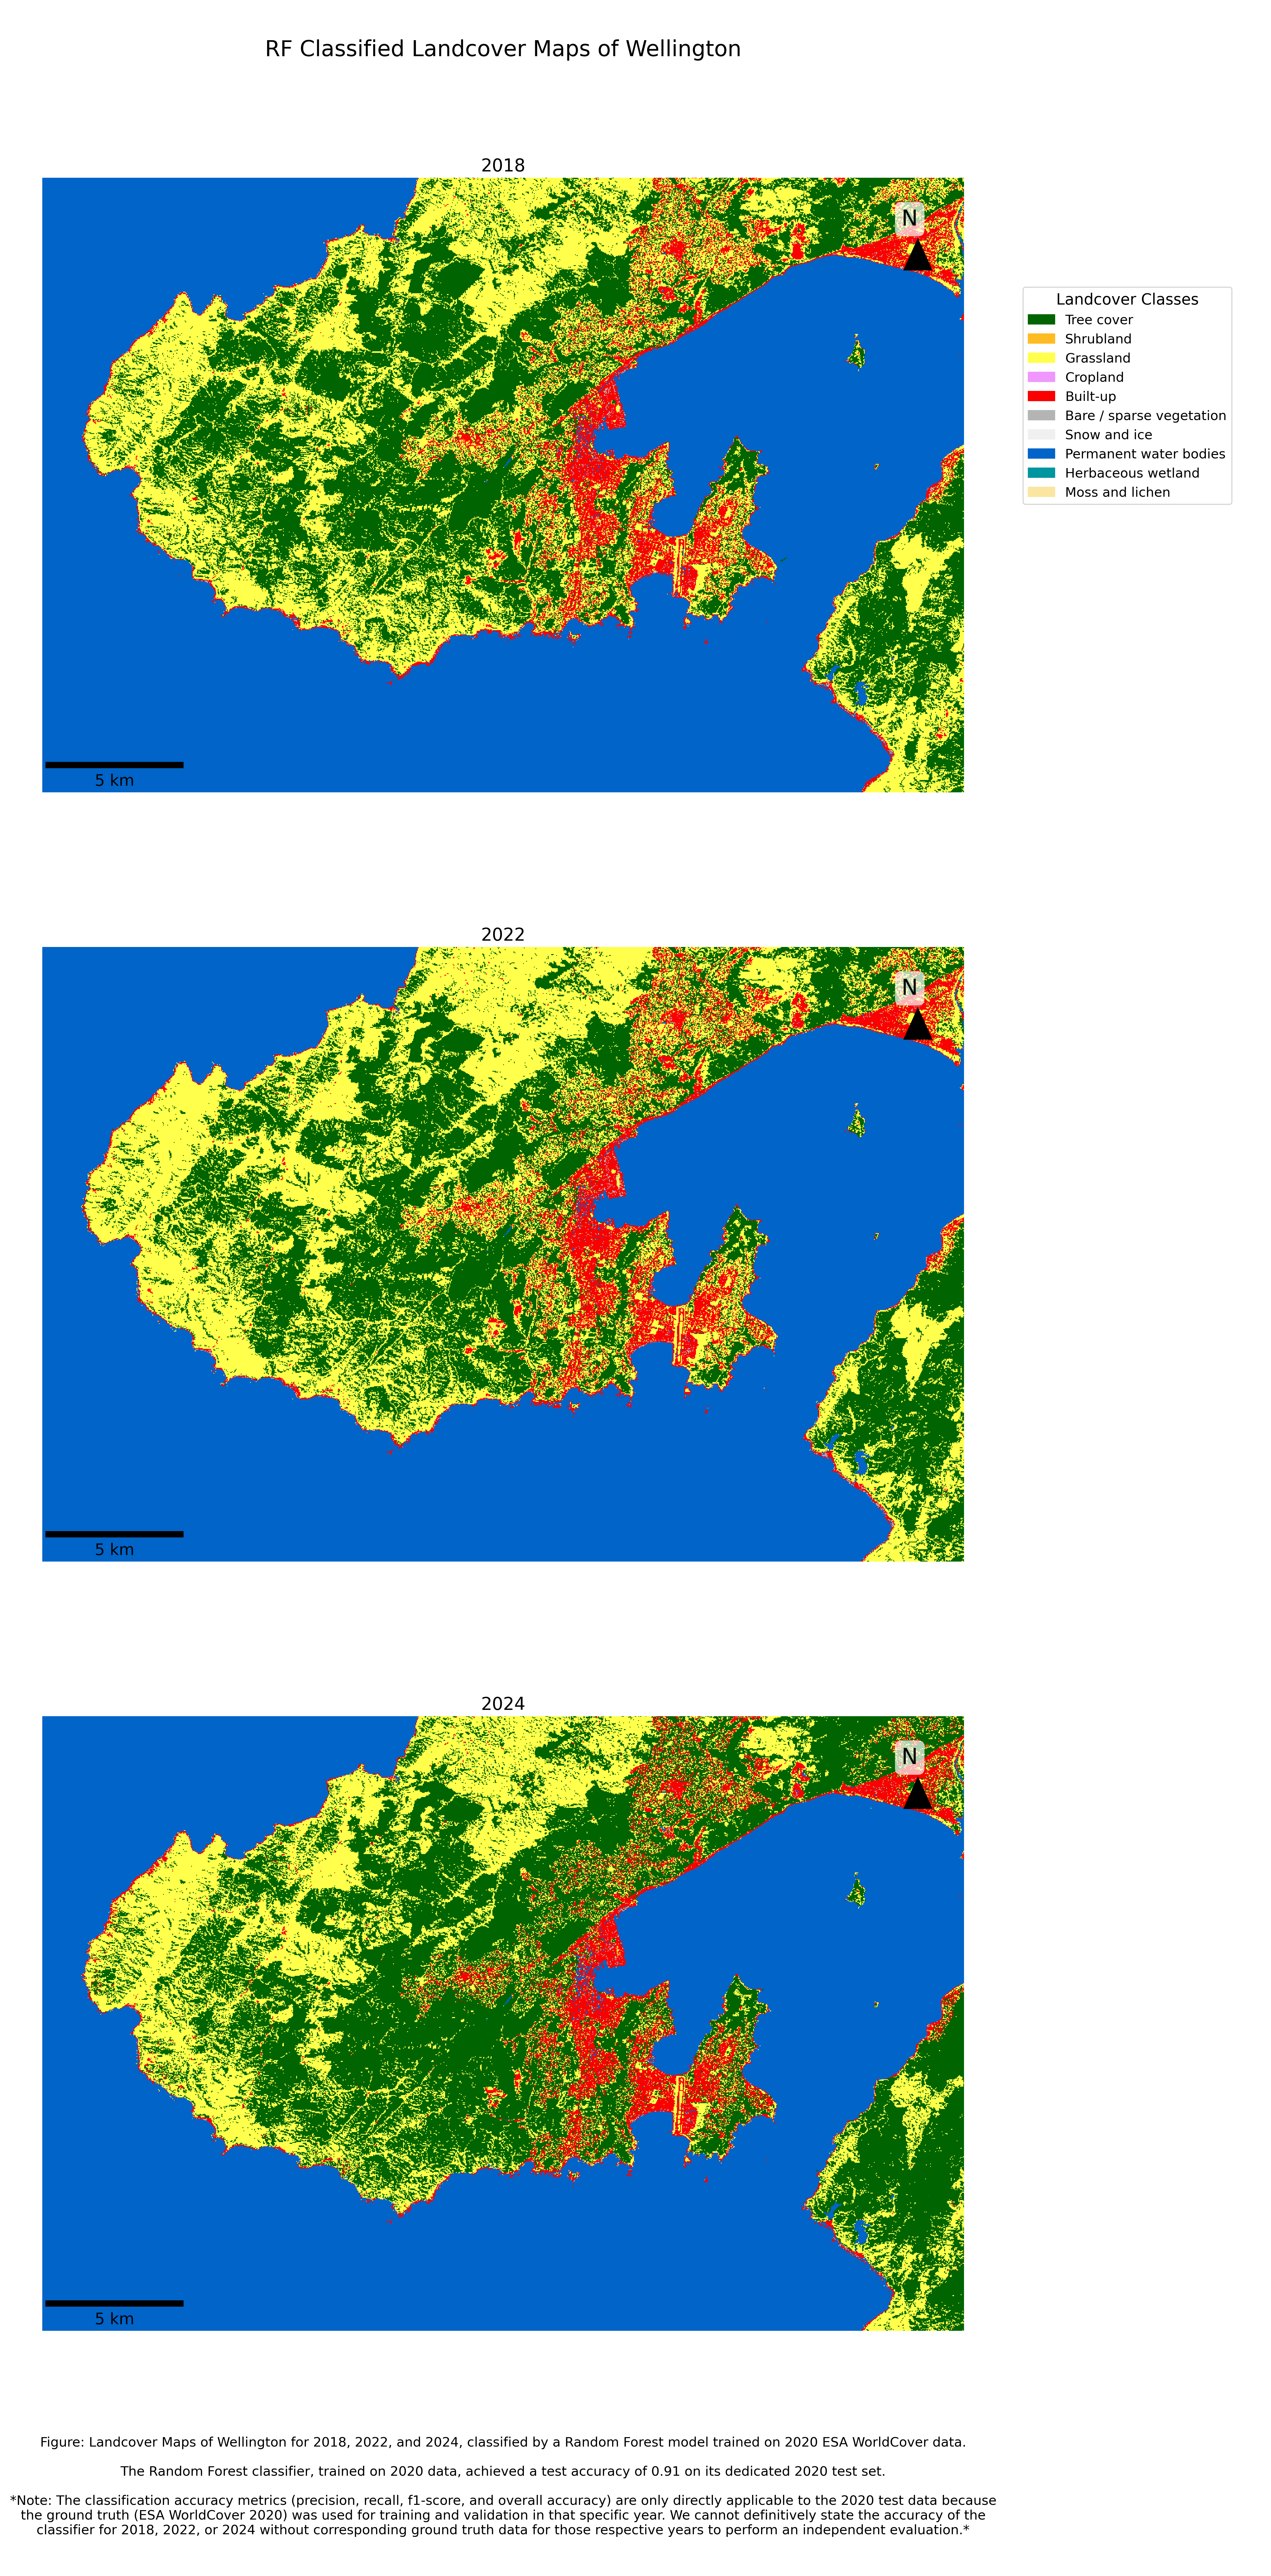

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
from IPython.display import Image
from matplotlib_scalebar.scalebar import ScaleBar # Corrected Import ScaleBar

# Define the years for which to generate maps
years = [2018, 2022, 2024]

# Prepare data for plotting
classified_np_arrays = {}
for year in years:
    print(f"Processing {year}...")
    # Call the refactored function
    np_array, ee_image = get_classified_image_for_year(year, aoi, classifier, bands, mask_s2_clouds)
    if np_array is not None:
        classified_np_arrays[year] = np_array
    else:
        print(f"Could not get classified data for {year}.")

# Only proceed if we have data for all years
if len(classified_np_arrays) == len(years):
    # Create a colormap from the hex colors defined in landcover_colors
    cmap = mcolors.ListedColormap([f'#{c}' for c in landcover_colors])
    # Define bounds for each class (1 to 10 for 10 classes)
    bounds = np.arange(1, len(landcover_names) + 2) # Bounds for 10 classes: [1, 2, ..., 11]
    norm = mcolors.BoundaryNorm(bounds, cmap.N) # Normalize the color mapping

    # Create the figure with 3 subplots arranged vertically
    fig, axes = plt.subplots(3, 1, figsize=(12, 30), sharex=True, sharey=True)
    fig.suptitle('RF Classified Landcover Maps of Wellington', fontsize=20, y=1.005)

    for i, year in enumerate(years):
        ax = axes[i]
        im = ax.imshow(classified_np_arrays[year], cmap=cmap, norm=norm)
        ax.set_title(f'{year}', fontsize=16)
        ax.axis('off') # Turn off axes for a cleaner map look

        # Add scale bar (30 meters per pixel, as specified in ee_to_numpy scale)
        # Removed 'length_factor' as it caused a TypeError
        scalebar = ScaleBar(30, units="m", location='lower left', frameon=False, box_alpha=0, font_properties={'size': 'x-large'})
        ax.add_artist(scalebar)

        # Add north arrow (simple text annotation)
        ax.text(0.95, 0.95, 'N', transform=ax.transAxes, fontsize=20, va='top', ha='right',
                bbox=dict(boxstyle="round,pad=0.3", fc='white', ec='none', lw=0, alpha=0.7))
        ax.arrow(0.95, 0.85, 0, 0.05, transform=ax.transAxes, color='black', head_width=0.03, head_length=0.05,
                 length_includes_head=True, clip_on=False)


    # Create custom legend handles using patches (rectangles with appropriate colors and labels)
    patches = [mpatches.Patch(color=f'#{landcover_colors[i]}', label=landcover_names[i]) for i in range(len(landcover_names))]

    # Add a single common legend to the right of the subplots, adjust position and font size
    fig.legend(handles=patches, title="Landcover Classes", bbox_to_anchor=(1.05, 0.9), loc='upper left', borderaxespad=0., fontsize=12, title_fontsize=14)

    # Add the overall caption below the figure, increase font size and adjust position
    figure_caption = (
        "Figure: Landcover Maps of Wellington for 2018, 2022, and 2024, "
        "classified by a Random Forest model trained on 2020 ESA WorldCover data.\n\n"
        "The Random Forest classifier, trained on 2020 data, achieved a test accuracy of 0.91 on its dedicated 2020 test set.\n\n"
        "*Note: The classification accuracy metrics (precision, recall, f1-score, and overall accuracy) are only directly applicable "
        "to the 2020 test data because the ground truth (ESA WorldCover 2020) was used for training and validation in that specific year. "
        "We cannot definitively state the accuracy of the classifier for 2018, 2022, or 2024 without corresponding ground truth data "
        "for those respective years to perform an independent evaluation.*"
    )
    # Adjusted figtext position (y to -0.05) to move it further down, combined with tight_layout and pad_inches it should fit
    plt.figtext(0.5, -0.05, figure_caption, ha="center", fontsize=12, wrap=True, bbox={"facecolor":"white", "alpha":0, "pad":5})

    # Adjust layout to prevent labels/legend/caption from being cut off and save the figure
    # Using fig.subplots_adjust to explicitly make room for the bottom caption
    fig.subplots_adjust(bottom=0.15) # Adjust this value if caption is still cut off or too far
    plt.tight_layout()

    output_dir = 'output_maps'
    os.makedirs(output_dir, exist_ok=True)
    output_filename = os.path.join(output_dir, 'classified_landcover_figure_publication_quality.png')
    plt.savefig(output_filename, bbox_inches='tight', dpi=300, pad_inches=0.5)
    plt.close(fig) # Close the figure to free up memory

    print(f"Generated publication-quality figure: {output_filename}")
    display(Image(filename=output_filename))
else:
    print("Could not generate figure as data for all years was not available.")

---

# SVMs Applied to Satellite Data

In [19]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [20]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/LCDB_v5.shp") #<- Check file names
print(gdf.head())


KeyboardInterrupt: 